In [1]:
import PyPDF2
from pdf2image import convert_from_bytes
from PIL import Image
from IPython.display import display

In [2]:
def crop_pdf_to_memory(input_pdf, crop_box):
    """
    Crop all pages in the PDF according to crop_box and return a PdfWriter object (unsaved).
    """
    reader = PyPDF2.PdfReader(input_pdf)
    writer = PyPDF2.PdfWriter()

    for page in reader.pages:
        page.mediabox.lower_left = [crop_box[0], crop_box[1]]
        page.mediabox.upper_right = [crop_box[2], crop_box[3]]
        writer.add_page(page)

    return writer


def writer_to_bytes(writer):
    """
    Write the PdfWriter content to bytes.
    """
    import io

    output_stream = io.BytesIO()
    writer.write(output_stream)
    output_stream.seek(0)
    return output_stream


def display_pdf_preview(pdf_stream):
    """
    Convert PDF bytes to images and display them.
    """
    images = convert_from_bytes(pdf_stream.getvalue())
    for img in images:
        display(img)


def get_pdf_page_sizes(input_pdf):
    reader = PyPDF2.PdfReader(input_pdf)
    sizes = []
    for i, page in enumerate(reader.pages):
        mediabox = page.mediabox
        width = float(mediabox.width)
        height = float(mediabox.height)
        sizes.append((width, height))
        print(f"Page {i + 1}: width = {width} pt, height = {height} pt")
    return sizes

Page 1: width = 576.0 pt, height = 288.0 pt
[(576.0, 288.0)]


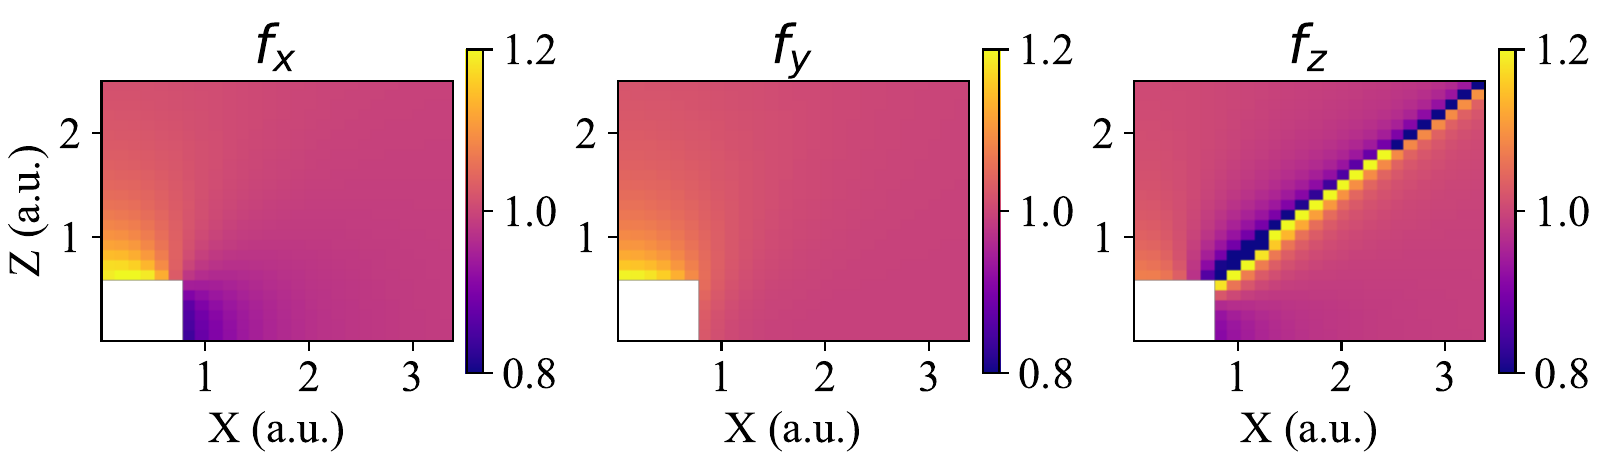

correction-factors/mult_factors_cropped.pdf


In [9]:
input_pdf = "correction-factors/mult_factors.pdf"

size = get_pdf_page_sizes(input_pdf)
print(size)

# OPTION 1
left_lower = 0, 50
right_upper = 580, 220

# OPTION 2
# left_lower = 50, 120
# right_upper = 405, 330

# OPTION 3
# left_lower = 0, 0
# right_upper = 405, 330

# OPTION 4
# left_lower = 50, 0
# right_upper = 405, 330

crop_box = (*left_lower, *right_upper)

# Crop but don't save yet
writer = crop_pdf_to_memory(input_pdf, crop_box)

# Convert writer to in-memory bytes
pdf_stream = writer_to_bytes(writer)

# Preview in notebook
display_pdf_preview(pdf_stream)

save_path = f"{input_pdf[:-4]}_cropped.pdf"
print(save_path)

with open(save_path, "wb") as f_out:
    f_out.write(pdf_stream.read())